# 04 · Final evaluation and explainability

The selected model (lowest CV error) was refit on the full 80 % training portion by
`python -m car_price.train --final`. This notebook scores the **untouched test set once** and explains the model.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from car_price.config import load_config, resolve
from car_price.data import TARGET, clean, load_dataset

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight"})
cfg = load_config()
FIG = resolve(cfg, "figures"); FIG.mkdir(parents=True, exist_ok=True)

import joblib
from car_price.evaluate import metrics, plot_pred_vs_actual, segment_report, split_train_test
res = resolve(cfg, "results")
model = joblib.load(resolve(cfg, "models") / "final_model.joblib")
raw, source = load_dataset(cfg)
train, test = split_train_test(clean(raw, cfg), cfg)
Xte, yte = test.drop(columns=TARGET), test[TARGET]
pred = model.predict(Xte)
lb = pd.read_csv(res / "cv_leaderboard.csv").sort_values("mae_log_mean")
print("final model:", lb.iloc[0].model, "| test rows:", len(test))

final model: lgbm | test rows: 20238


## Test-set performance vs cross-validation
If the test numbers sit inside the CV ± std band, the CV estimate was honest (no over-fitting to validation folds).

In [2]:
tm = metrics(yte, pred)
cv = lb.iloc[0]
pd.DataFrame({"CV mean": [cv.mae_mean, cv.mape_mean, cv.r2_mean], "CV std": [cv.mae_std, cv.mape_std, cv.r2_std],
              "Test": [tm["mae"], tm["mape"], tm["r2"]]}, index=["MAE (€)", "MAPE", "R²"]).round(3)

,CV mean,CV std,Test
MAE (€),2123.955,159.541,1988.060
MAPE,0.120,0.002,0.115
R²,0.658,0.176,0.824


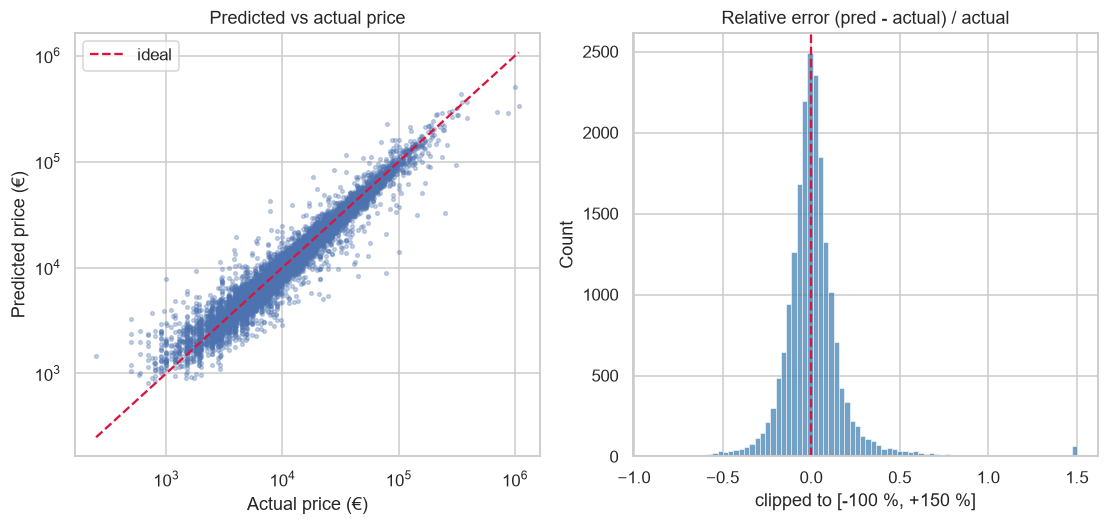

within ±10 %: 63.4%   within ±20 %: 86.7%


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_pred_vs_actual(yte, pred, ax=axes[0])
rel = (pred - yte) / yte
sns.histplot(rel.clip(-1, 1.5), bins=80, ax=axes[1], color="steelblue")
axes[1].axvline(0, color="crimson", ls="--"); axes[1].set(title="Relative error (pred - actual) / actual", xlabel="clipped to [-100 %, +150 %]")
fig.savefig(FIG / "test_predictions.png"); plt.show()
print(f"within ±10 %: {(rel.abs() <= .10).mean():.1%}   within ±20 %: {(rel.abs() <= .20).mean():.1%}")

## Where does the model struggle?
Error per brand segment. Rare premium segments have the fewest examples and the widest price spread.

In [4]:
seg = segment_report(model, Xte, yte)
seg["MAPE"] = (seg.MAPE * 100).round(1); seg["MedAPE"] = (seg.MedAPE * 100).round(1); seg["MAE"] = seg.MAE.round(0)
seg

,n,MAPE,MedAPE,MAE
segment,,,,
Utility Vehicle,2,92.3,92.3,4263.0
Niche,613,23.6,12.2,3602.0
High Luxury,462,16.2,9.1,16173.0
Ordinary,13375,11.5,7.0,1209.0
Luxury,5786,9.9,6.6,2484.0


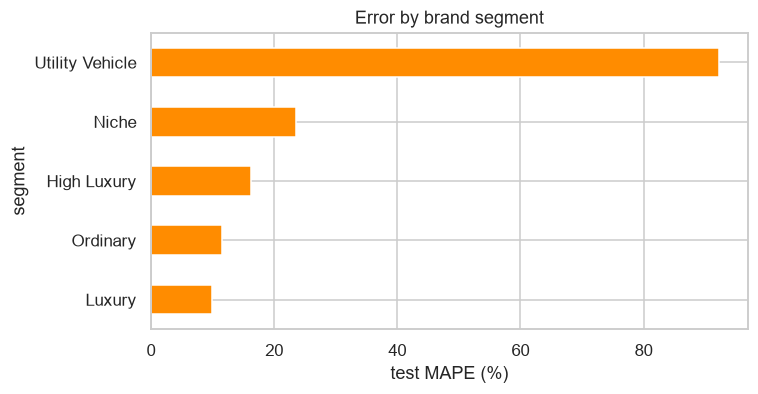

In [5]:
fig, ax = plt.subplots(figsize=(7, 3.5))
seg.sort_values("MAPE").MAPE.plot.barh(ax=ax, color="darkorange"); ax.set(xlabel="test MAPE (%)", title="Error by brand segment")
plt.show()

## Explaining the model with SHAP
Global drivers of the predicted (log) price, plus one individual prediction.

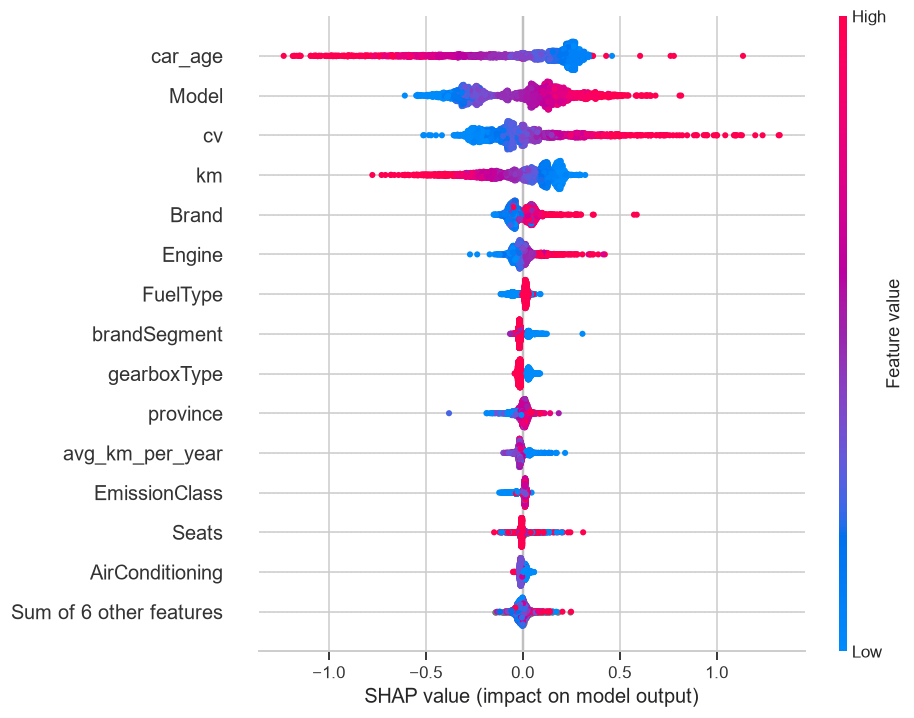

In [6]:
import shap
reg = model.regressor_
feats = reg.named_steps["prep"].transform(reg.named_steps["features"].transform(Xte))
est = reg.named_steps["model"]
est = getattr(est, "model_", est)                        # unwrap the CatBoost wrapper
sample = feats.sample(min(2500, len(feats)), random_state=cfg["seed"])
explainer = shap.TreeExplainer(est)
sv = explainer(sample)
shap.plots.beeswarm(sv, max_display=15, show=False)
plt.gcf().savefig(FIG / "shap_beeswarm.png", bbox_inches="tight"); plt.show()

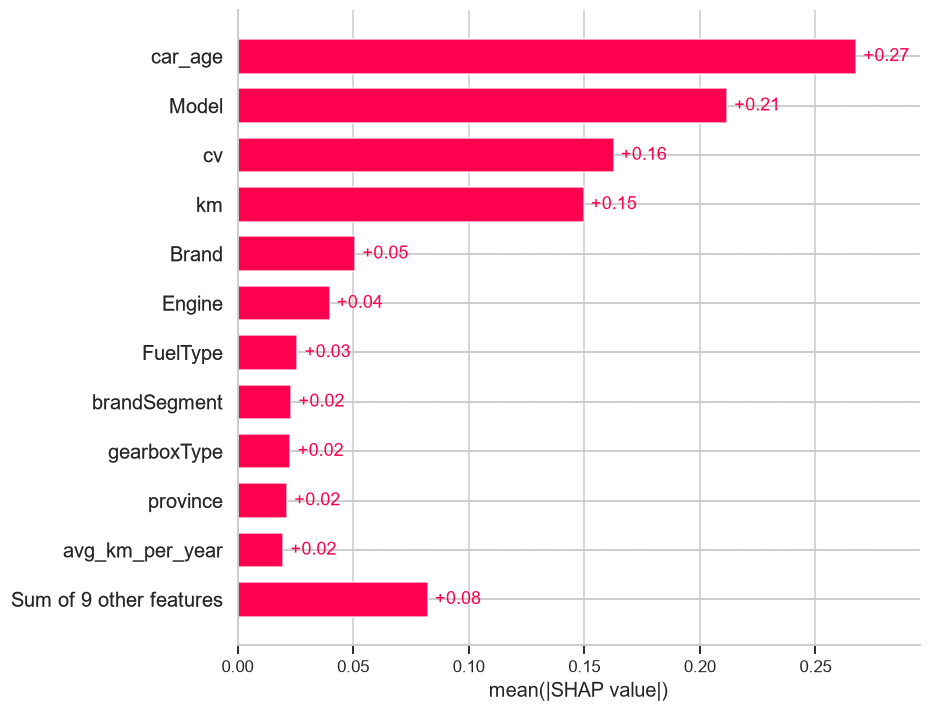

In [7]:
shap.plots.bar(sv, max_display=12, show=False)
plt.show()

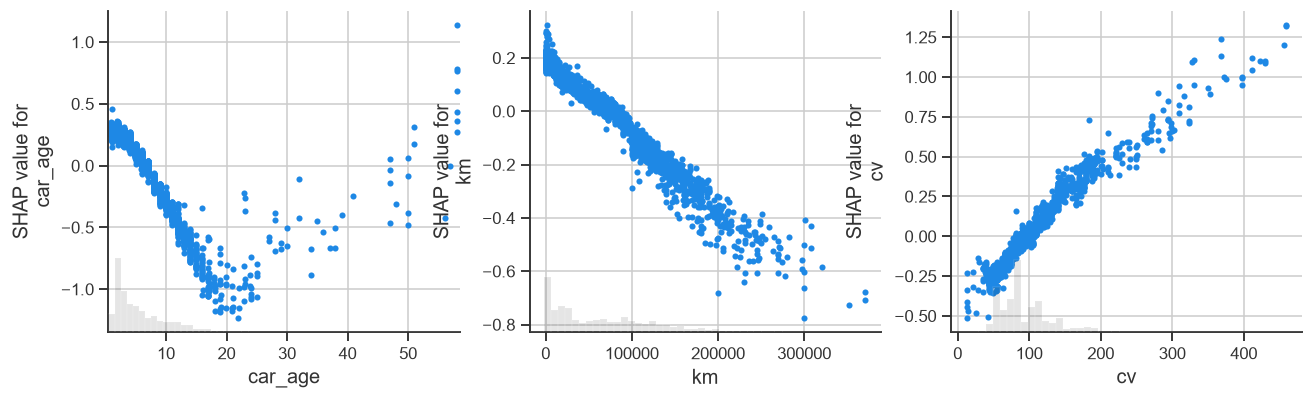

In [8]:
top = ["car_age", "km", "cv"]
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for ax, f in zip(axes, top):
    shap.plots.scatter(sv[:, f], ax=ax, show=False)
plt.show()

MERCEDES-BENZ Classe CLA · 2017 · 5,848 km · 100 cv  ->  actual 33,000 €, predicted 32,632 €


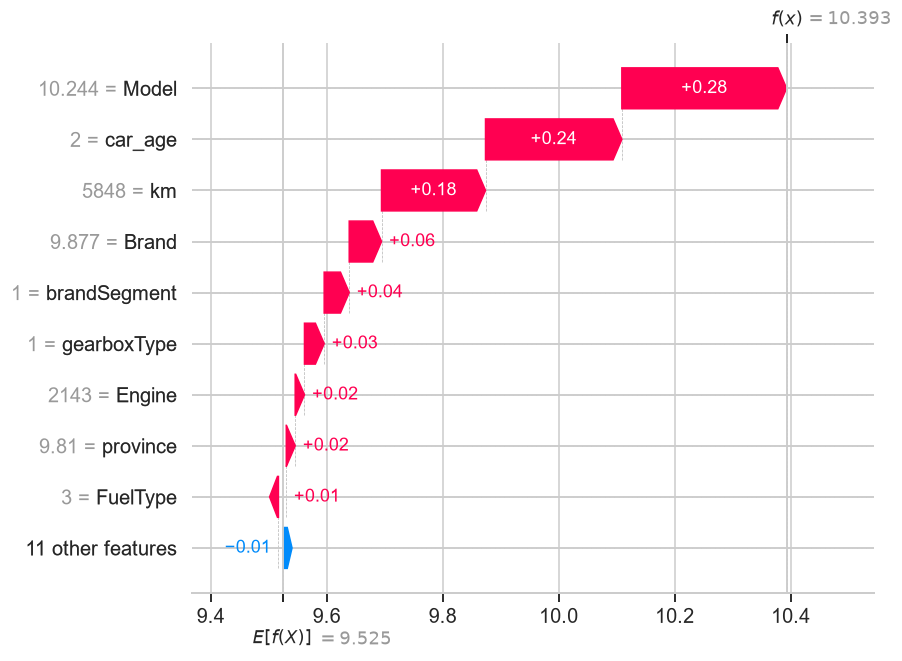

In [9]:
i = 0
row = Xte.loc[sample.index[i]]
print(f"{row.Brand} {row.Model} · {int(row.MatriculationYear)} · {row.km:,.0f} km · {row.cv:.0f} cv"
      f"  ->  actual {yte.loc[sample.index[i]]:,.0f} €, predicted {model.predict(Xte.loc[[sample.index[i]]])[0]:,.0f} €")
shap.plots.waterfall(sv[i], max_display=10, show=False)
plt.show()

## Limitations and next steps
* Listings are **asking prices**, not transaction prices; a real deployment would want sold prices.
* The data is a 2019 snapshot: the model does not capture market shifts over time. A time-based split is the honest test of that.
* Point predictions only; quantile regression or conformal intervals would give a usable price *range*.
* Rare luxury/niche brands remain the weakest segments: more data or a hierarchical brand prior would help.